#### Practicing (personal review) of Monte Carlo Methods

Expected Average Profit: $69,744.34
Probability of making a loss: 0.00%
95% Confidence Interval for Profit: $31,892.62 to $114,610.53


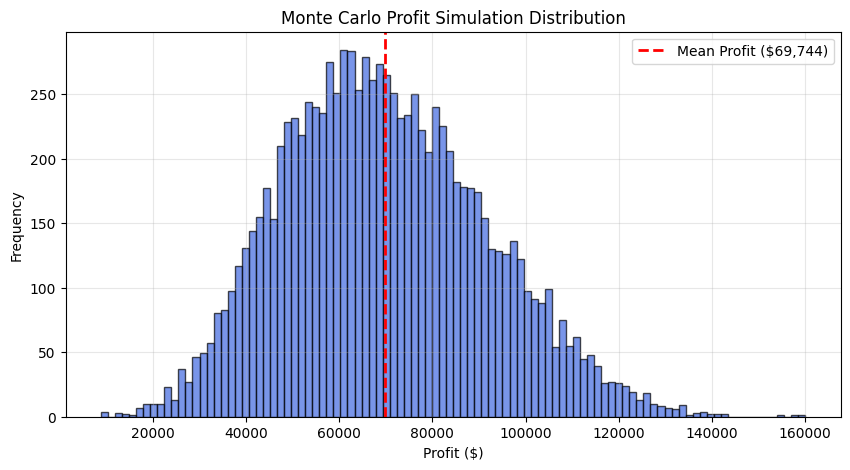

In [2]:
import numpy as np
import matplotlib.pyplot as plt

simulations = 10000 # we are running 10^5 simulations 

sales_volume = np.random.normal(loc=5000, scale=800, size=simulations)

# Unit price follows a uniform distribution (ranging between $15 and $25)
unit_price = np.random.uniform(low=15, high=25, size=simulations)

# Fixed overhead cost
fixed_costs = 30000

# Perform the deterministic calculation across all samples
total_revenue = sales_volume * unit_price
total_profit = total_revenue - fixed_costs

# Aggregate and analyze results
print(f"Expected Average Profit: ${np.mean(total_profit):,.2f}")
print(f"Probability of making a loss: {np.mean(total_profit < 0) * 100:.2f}%")
print(f"95% Confidence Interval for Profit: ${np.percentile(total_profit, 2.5):,.2f} to ${np.percentile(total_profit, 97.5):,.2f}")

# Visualize the outcome distribution
plt.figure(figsize=(10, 5))
plt.hist(total_profit, bins=100, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(total_profit), color='red', linestyle='dashed', linewidth=2, label=f'Mean Profit (${np.mean(total_profit):,.0f})')
plt.title('Monte Carlo Profit Simulation Distribution')
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Monte Carlo Methods Applied to Healthcare Scenarios 

Here we look at the following: 

- A Monte Carlo simulation of a drug’s pipeline probability of success
- Calculate the resulting Value-at-Risk (VaR) for the fund
- Real options valuation for pharma R&D

In [ ]:
# Monte Carlo Simulation of a Drug's Pipeline Proability of Success
# Inspired by the paper "Simulation the drug discovery pipeline: a Monte Carlo approach"
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

# number of simulations 
n_simulations = 10000
np.random.seed(np.random.randint(20,70)) # to increase reproducibility

# go/no-go milestones
# key milestones
# Here are some real world standard benchmarks to consider
# Phase I to Phase II: \(50\% - 60\%\)
# Phase II to Phase III: \(25\% - 35\%\)
# Phase III to NDA/BLA: \(55\% - 65\%\)
# Regulatory Approval: \(85\% - 95\%\)

# note to self to also make the size of the distirbution the number of simulations
p_phaseI = np.random.uniform(low=0.5,high=0.6,size=n_simulations)
p_phaseII = np.random.uniform(low=0.25,high=0.35,size=n_simulations)
p_phaseIII = np.random.uniform(low=0.55,high=0.65,size=n_simulations)
p_reg = np.random.uniform(low=0.85, high=0.95,size=n_simulations)

# Cost distribution 
c_phaseI = np.random.triangular(5, 10, 15, size=n_simulations)
c_phaseII = np.random.triangular(15, 30, 45, size=n_simulations)
c_phaseIII = np.random.triangular(40, 90, 150, size=n_simulations)
c_reg = np.random.triangular(2, 3, 5, size=n_simulations)

# Timeline distirbutions 
t_phaseI = np.random.lognormal(mean=0.4, sigma=0.2, size=n_simulations)      # ~1.5 years
t_phaseII = np.random.lognormal(mean=0.9, sigma=0.2, size=n_simulations)     # ~2.5 years
t_phaseIII = np.random.lognormal(mean=1.2, sigma=0.2, size=n_simulations)    # ~3.5 years
t_reg = np.random.lognormal(mean=0.1, sigma=0.1, size=n_simulations)         # ~1.1 years

# phase I = 5, 15 million (1-2 yrs)
# phase II = 15, 45 million (2-3 yrs)
# phae III = 40, 150 million (3-4 yrs)
# regulatory = 2,5 millions (1-1.5 yrs)
# Track success using arrays
phaseI_success = np.zeros(n_simulations)
phaseII_success = np.zeros(n_simulations)
phaseIII_success = np.zeros(n_simulations)
reg_success = np.zeros(n_simulations)
cost_success = np.zeros(n_simulations)

# Run the simulation (basic logic)
for i in range(n_simulations):
    # Phase I Regulatory Stage
    if np.random.rand() <= p_phaseI[i]:
        phaseI_success[i] = 1

        # Phase II Regulatory Stage
        if np.random.rand() <= p_phaseII[i]:
            phaseII_success[i] = 1

            # Phase III Regulatory Stage
            if np.random.rand() <= p_phaseIII[i]:
                phaseIII_success[i] = 1

                # Regulatory Approval Stage
                if np.random.rand() <= p_reg[i]:
                    reg_success[i] = 1


# Aggregate and analyze results
print("\n--- Pass Rate of Regulatory Phases and PTRS ---")
print(f"Overall Cumulative PTRS: {np.mean(reg_success):,.2f}")
print(f"Phase I Pass Rate: {np.mean(phaseI_success) * 100:.2f}%")
print(f"Phase II Pass Rate: {np.mean(phaseII_success) * 100:,.2f}%")

# Cost and time analysis (now tracking failure modes)
overall_success = np.zeros(n_simulations)
total_costs = np.zeros(n_simulations)
total_time = np.zeros(n_simulations)
failure_phase = [] 

for i in range(n_simulations):
    # Phase I
    total_costs[i] += c_phaseI[i]
    total_time[i] += t_phaseI[i]
    
    if np.random.rand() > p_phaseI[i]:
        failure_phase.append("Phase I Failure")
        continue # Drug failed
        
    # Phase II
    total_costs[i] += c_phaseII[i]
    total_time[i] += t_phaseII[i]
    
    if np.random.rand() > p_phaseII[i]:
        failure_phase.append("Phase II Failure")
        continue
        
    # Phase III
    total_costs[i] += c_phaseIII[i]
    total_time[i] += t_phaseIII[i]
    
    if np.random.rand() > p_phaseIII[i]:
        failure_phase.append("Phase III Failure")
        continue
    
    # Regulatory Phase
    total_costs[i] += c_reg[i]
    total_time[i] += t_reg[i]
    
    if np.random.rand() > p_reg[i]:
        failure_phase.append("Regulatory Failure")
        continue
        
    # If the project survives
    overall_success[i] = 1
    failure_phase.append("Approved")

# put results in dataframe for future analysis/plotting
results = pd.DataFrame({
    'Success': overall_success,
    'Total_Cost_Millions': total_costs,
    'Total_Time_Years': total_time,
    'Outcome': failure_phase
})

print(f"Overall Pipeline Success Rate: {results['Success'].mean() * 100:.2f}%")
print(f"Average Cost of ANY Pipeline Attempt: ${results['Total_Cost_Millions'].mean():.2f}M")
print(f"Average Time Expended per Attempt: {results['Total_Time_Years'].mean():.2f} Years")

print("\n--- Cost Breakdown by Final Outcome ---")
print(results.groupby('Outcome')['Total_Cost_Millions'].mean().map('${:,.2f}M'.format))

# Calculate the Net Present Value (NPV)
# Peak annual sales if approved: Log-normal because blockbuster drug revenues are heavily right-skewed
peak_sales = np.random.lognormal(mean=5.3, sigma=0.6, size=n_simulations) 
commercial_life = np.random.randint(8, 13, size=n_simulations) 

# define empty arrays
overall_success = np.zeros(n_simulations)
total_costs = np.zeros(n_simulations)
total_time = np.zeros(n_simulations)
npv_results = np.zeros(n_simulations)
discount_rate = 0.1
failure_phase = []

for i in range(n_simulations):
    current_time = 0
    pv_costs = 0
    
    # Phase I
    pv_costs += c_phaseI[i] / ((1 + discount_rate) ** (current_time + t_phaseI[i]/2)) # using mathematical formula for npv
    current_time += t_phaseI[i]
    if np.random.rand() > p_phaseI[i]:
        failure_phase.append("Phase I Failure")
        npv_results[i] = -pv_costs
        total_costs[i] = c_phaseI[i]
        total_time[i] = current_time
        continue
        
    # Phase II
    pv_costs += c_phaseII[i] / ((1 + discount_rate) ** (current_time + t_phaseII[i]/2))
    current_time += t_phaseII[i]
    if np.random.rand() > p_phaseII[i]:
        failure_phase.append("Phase II Failure")
        npv_results[i] = -pv_costs
        total_costs[i] = c_phaseI[i] + c_phaseII[i]
        total_time[i] = current_time
        continue
        
    # Phase III
    pv_costs += c_phaseIII[i] / ((1 + discount_rate) ** (current_time + t_phaseIII[i]/2))
    current_time += t_phaseIII[i]
    if np.random.rand() > p_phaseIII[i]:
        failure_phase.append("Phase III Failure")
        npv_results[i] = -pv_costs
        total_costs[i] = c_phaseI[i] + c_phaseII[i] + c_phaseIII[i]
        total_time[i] = current_time
        continue
        
    # Regulatory
    pv_costs += c_reg[i] / ((1 + discount_rate) ** (current_time + t_reg[i]/2))
    current_time += t_reg[i]
    if np.random.rand() > p_reg[i]:
        failure_phase.append("Regulatory Failure")
        npv_results[i] = -pv_costs
        total_costs[i] = c_phaseI[i] + c_phaseII[i] + c_phaseIII[i] + c_reg[i]
        total_time[i] = current_time
        continue
        
    # calculate commercial revenue
    overall_success[i] = 1
    failure_phase.append("Approved")
    total_costs[i] = c_phaseI[i] + c_phaseII[i] + c_phaseIII[i] + c_reg[i]
    total_time[i] = current_time
    
    # Calculate Present Value of Commercial Earnings
    pv_revenue = 0
    for year in range(1, commercial_life[i] + 1):
        # Simplified cash flow: ramping up to peak sales, assuming a 25% net profit margin
        annual_profit = peak_sales[i] * 0.25 
        # Discount revenue back to Year 0
        pv_revenue += annual_profit / ((1 + discount_rate) ** (current_time + year))
        
    npv_results[i] = pv_revenue - pv_costs

# Process Results
results = pd.DataFrame({
    'Outcome': failure_phase,
    'Success': overall_success,
    'Total_Cost': total_costs,
    'Total_Time': total_time,
    'NPV_Millions': npv_results
})

# Summary output
print(f"Overall Pipeline Success Rate: {results['Success'].mean() * 100:.2f}%")
print(f"Project Expected NPV (eNPV): ${results['NPV_Millions'].mean():.2f}M")

print("\n--- Average Financial Outcome (NPV) by Stage ---")
print(results.groupby('Outcome')['NPV_Millions'].mean().map('${:,.2f}M'.format))


--- Pass Rate of Regulatory Phases and PTRS ---
Overall Cumulative PTRS: 0.09
Phase I Pass Rate: 55.38%
Phase II Pass Rate: 17.39%
Overall Pipeline Success Rate: 8.88%
Average Cost of ANY Pipeline Attempt: $42.06M
Average Time Expended per Attempt: 3.56 Years

--- Cost Breakdown by Final Outcome ---
Outcome
Approved              $135.80M
Phase I Failure         $9.97M
Phase II Failure       $40.11M
Phase III Failure     $132.05M
Regulatory Failure    $137.13M
Name: Total_Cost_Millions, dtype: str
Overall Pipeline Success Rate: 8.50%
Project Expected NPV (eNPV): $-17.34M

--- Average Financial Outcome (NPV) by Stage ---
Outcome
Approved               $68.59M
Phase I Failure        $-9.29M
Phase II Failure      $-32.38M
Phase III Failure     $-85.94M
Regulatory Failure    $-89.99M
Name: NPV_Millions, dtype: str


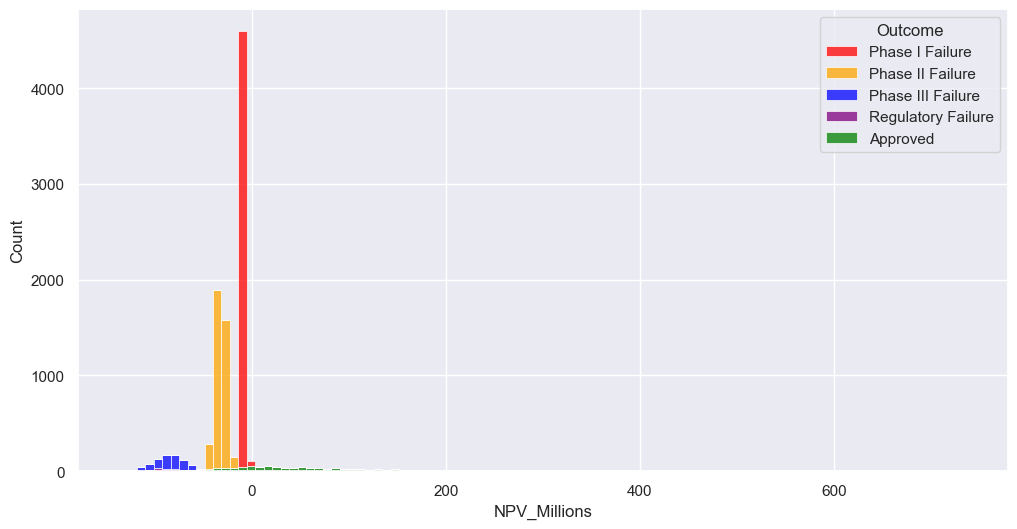

<Figure size 640x480 with 0 Axes>

In [ ]:
# Use seaborn to plot a histogram of NPV millions 
import seaborn as sns

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(12,6))

# Define color palette 
palette = {
    "Phase I Failure": "red",
    "Phase II Failure": "orange",
    "Phase III Failure": "blue",
    "Regulatory Failure": "purple",
    "Approved": "green"
}

# Make a histogram plot
sns.histplot(data = results, 
             x="NPV_Millions",
             hue="Outcome",
             hue_order = ["Phase I Failure", "Phase II Failure", "Phase III Failure", "Regulatory Failure", "Approved"],
             palette = palette,
             multiple="stack",
             bins = 100,
             ax = ax,
             edgecolor = 'white',
             linewidth = 0.5)
plt.show()

# Add clear indicators for Expected NPV (eNPV)
enpv = results['NPV_Millions'].mean()
ax.axvline(enpv, color='blue', linestyle='--', linewidth=2, label=f'Expected NPV (eNPV): ${enpv:.2f}M')

# Add a line at $0 to clearly delineate loss vs profit
ax.axvline(0, color='black', linestyle='-', linewidth=1) # still working on this line

# Plot!
ax.set_title("Distribution of Pipeline Net Present Value (NPV)\nStacked by Attrition Stage vs. Success", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Net Present Value ($ Millions)", fontsize=12)
ax.set_ylabel("Count of Simulation Runs", fontsize=12)

ax.legend(title="Pipeline Outcome", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()

